# Final Project: Venture Capital Market Intelligence

This notebook contains the logic to import the Crunchbase data to your MongoDB instance.

You should expand on this notebook to include the logic **and outputs** necessary for the final project.

## Prepare MongoDB
You are likely reaching the limits of the storage in your free MongoDB instance.

**PRIOR to loading the data**, you should clean up some of the unneeded databases from your MongoDB instance. Log into MongoDB Atlas and manually delete one or more of the following:

- `sample_mflix`
- `sample_airbnb`
- `nyc`

This should free up enough space to load the data for the final project.

## Project Setup

In [ ]:
# Python setup to install required libraries
# Run this cell once per session
# Add additional packages as needed

!pip install pymongo
from pymongo import MongoClient
from pymongo.errors import BulkWriteError
from google.cloud import storage
import json

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 30.0 MB/s eta 0:00:00


In [ ]:
# Make a connection to the database using the querystring
# Insert your querystring below
# Run this cell once per session

import pymongo
from pymongo.mongo_client import MongoClient

# ⚠️ REPLACE this placeholder with your actual MongoDB connection string
# This string should typically look like:
# "mongodb+srv://<username>:<password>@<cluster-url>/<options>"
MONGODB_URI = "mongodb+srv://nchopde_db_user:@cluster0.u8esx8y.mongodb.net/?appName=Cluster0"


try:
    # Create a new client and connect to the server
    client = MongoClient(MONGODB_URI)

    # Ping the server to check for a successful connection
    client.admin.command('ping')
    print("✅ Successfully connected to MongoDB!")

except Exception as e:
    print(f"❌ Connection failed: {e}")
    # You might need to check your firewall (IP whitelist) in MongoDB Atlas

✅ Successfully connected to MongoDB!


# Preparation: Obtain Crunchbase Data

The data for this notebook is stored in a JSON file in a Google Cloud Storage bucket. You will download the file and upload it into your MongoDB instance.

## Download the Data

In [ ]:
# GCP bucket information
GCP_BUCKET_NAME = "advdb-course-data"
PRODUCT_FILE = "crunchbase/crunchbase_companies.json"

def download_from_gcs(bucket_name, source_blob_name, destination_file_name):
    """
    Download a file from Google Cloud Storage
    """
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} from bucket {bucket_name} to {destination_file_name}")

# Download the companies file
local_file = "crunchbase_companies.json"
download_from_gcs(GCP_BUCKET_NAME, PRODUCT_FILE, local_file)

Downloaded crunchbase/crunchbase_companies.json from bucket advdb-course-data to crunchbase_companies.json


## Create a Database in MongoDB Atlas

In [ ]:
# Create the database and collection in MongoDB Atlas
db = client['crunchbase']  # Database name
companies_collection = db['companies']  # Collection name

## Load the Data to MongoDB Atlas

In [ ]:
# Load JSON data and insert into MongoDB
# Note: The file should contain one JSON object per line (JSONL format)

# Clear existing data (optional - use with caution!)
companies_collection.delete_many({})

companies = []
with open(local_file, 'r') as file:
    for line in file:
        try:
            company = json.loads(line.strip())
            companies.append(company)
        except json.JSONDecodeError:
            continue

# Set the desired batch size
BATCH_SIZE = 1000
total_inserted = 0

if companies:
    # Use a loop that iterates over the companies list in BATCH_SIZE steps
    for i in range(0, len(companies), BATCH_SIZE):
        # Slice the list to get the current batch
        batch = companies[i:i + BATCH_SIZE]

        try:
            # Insert the current batch into MongoDB
            result = companies_collection.insert_many(batch, ordered=False)

            inserted_count = len(result.inserted_ids)
            total_inserted += inserted_count
            print(f"Batch {i//BATCH_SIZE + 1}: Inserted {inserted_count} documents.")

        # except BulkWriteError as bwe:
        #     # This handles errors where some documents fail but others succeed
        #     # Use this if you want to inspect errors but continue processing
        #     total_inserted += bwe.details['nInserted']
        #     print(f"Batch {i//BATCH_SIZE + 1} partially failed, but inserted {bwe.details['nInserted']} documents.")
        #     # print(f"Write Errors: {bwe.details['writeErrors']}") # Uncomment to see specific errors

        except Exception as e:
            # Handle connection errors or other critical issues
            print(f"Critical error during batch {i//BATCH_SIZE + 1}: {e}")
            break # Stop processing if a critical error occurs

    print(f"\n✅ Finished insertion. Total documents inserted: {total_inserted}")

else:
    print("No companies to insert")

Batch 1: Inserted 1000 documents.
Batch 2: Inserted 1000 documents.
Batch 3: Inserted 1000 documents.
Batch 4: Inserted 1000 documents.
Batch 5: Inserted 1000 documents.
Batch 6: Inserted 1000 documents.
Batch 7: Inserted 1000 documents.
Batch 8: Inserted 1000 documents.
Batch 9: Inserted 1000 documents.
Batch 10: Inserted 1000 documents.
Batch 11: Inserted 1000 documents.
Batch 12: Inserted 1000 documents.
Batch 13: Inserted 1000 documents.
Batch 14: Inserted 1000 documents.
Batch 15: Inserted 1000 documents.
Batch 16: Inserted 1000 documents.
Batch 17: Inserted 1000 documents.
Batch 18: Inserted 1000 documents.
Batch 19: Inserted 801 documents.

✅ Finished insertion. Total documents inserted: 18801


In [ ]:
import json
from bson import ObjectId

def make_serializable(doc):
    """Convert ObjectId to string for pretty JSON output."""
    if not doc:
        return doc
    d = dict(doc)
    if isinstance(d.get("_id"), ObjectId):
        d["_id"] = str(d["_id"])
    return d

doc = companies_collection.find_one()

print("=== Single Document Sample (companies_collection) ===\n")
print(json.dumps(make_serializable(doc), indent=2))


=== Single Document Sample (companies_collection) ===

{
  "_id": "52cdef7c4bab8bd675297d8a",
  "name": "Wetpaint",
  "permalink": "abc2",
  "crunchbase_url": "http://www.crunchbase.com/company/wetpaint",
  "homepage_url": "http://wetpaint-inc.com",
  "blog_url": "http://digitalquarters.net/",
  "blog_feed_url": "http://digitalquarters.net/feed/",
  "twitter_username": "BachelrWetpaint",
  "category_code": "web",
  "number_of_employees": 47,
  "founded_year": 2005,
  "founded_month": 10,
  "founded_day": 17,
  "deadpooled_year": 1,
  "tag_list": "wiki, seattle, elowitz, media-industry, media-platform, social-distribution-system",
  "alias_list": "",
  "email_address": "info@wetpaint.com",
  "phone_number": "206.859.6300",
  "description": "Technology Platform Company",
  "created_at": {
    "$date": 1180075887000
  },
  "updated_at": "Sun Dec 08 07:15:44 UTC 2013",
  "overview": "<p>Wetpaint is a technology platform company that uses its proprietary state-of-the-art technology and expe

#Task 1: Data Transformation Pipeline (MongoDB)
Create a MongoDB aggregation pipeline that transforms the raw company documents into an analysis-ready collection.

In [ ]:

# TASK 1 — Data Transformation Pipeline (MongoDB)

pipeline = [
    {
        "$addFields": {
            "total_funding": {
                "$sum": {
                    "$map": {
                        "input": "$funding_rounds",
                        "as": "fr",
                        "in": { "$ifNull": ["$$fr.raised_amount", 0] }
                    }
                }
            },
            "founder_count": {
                "$size": {
                    "$filter": {
                        "input": "$relationships",
                        "as": "rel",
                        "cond": {
                            "$regexMatch": {
                                "input": "$$rel.title",
                                "regex": "founder",
                                "options": "i"
                            }
                        }
                    }
                }
            },
            "latest_funding_year": {
                "$max": {
                    "$map": {
                        "input": "$funding_rounds",
                        "as": "fr",
                        "in": "$$fr.funded_year"
                    }
                }
            }
        }
    },

    # fields required
    {
        "$project": {
            "_id": 1,
            "name": 1,
            "permalink": 1,
            "category_code": 1,
            "founded_year": 1,
            "founded_month": 1,
            "number_of_employees": 1,
            "total_funding": 1,
            "founder_count": 1,
            "latest_funding_year": 1,
            "offices": 1,
            "funding_rounds": 1
        }
    },

    # Pipeline results to new collection - companies_analysis
    {
        "$merge": {
            "into": "companies_analysis",
            "on": "_id",
            "whenMatched": "replace",
            "whenNotMatched": "insert"
        }
    }
]

# Run the pipeline
companies_collection.aggregate(pipeline)
print("Pipeline executed successfully! The collection 'companies_analysis' is now created/updated.")


#Document Count in companies_analysis
print("\nDOCUMENT COUNT IN companies_analysis:")
print(db.companies_analysis.count_documents({}))



Pipeline executed successfully! The collection 'companies_analysis' is now created/updated.

DOCUMENT COUNT IN companies_analysis:
18801


In [ ]:
# A sample of 3 documents from the new collection demonstrating your transformations worked correctly
print("\nSAMPLE OF 3 DOCUMENTS FROM companies_analysis:")
from pprint import pprint
for doc in db.companies_analysis.find().limit(3):
    pprint(doc)
    print("------------------------------------------------------------")


SAMPLE OF 3 DOCUMENTS FROM companies_analysis:
{'_id': '52cdef7d4bab8bd6752990b0',
 'category_code': 'software',
 'founded_month': 12,
 'founded_year': 1989,
 'founder_count': 0,
 'funding_rounds': [],
 'latest_funding_year': None,
 'name': 'Troolley',
 'number_of_employees': 14,
 'offices': [{'address1': 'Centro Direzionale San Giorgio',
              'address2': 'Viale Repubblica, 22',
              'city': 'Fontane di Villorba - Treviso',
              'country_code': 'ITA',
              'description': 'Headquarter',
              'latitude': None,
              'longitude': None,
              'state_code': None,
              'zip_code': 'i-3'}],
 'permalink': 'troolley',
 'total_funding': 0}
------------------------------------------------------------
{'_id': '52cdef7d4bab8bd675299b9c',
 'category_code': 'web',
 'founded_month': None,
 'founded_year': None,
 'founder_count': 0,
 'funding_rounds': [],
 'latest_funding_year': None,
 'name': 'AppCenter',
 'number_of_employees': No

#Task 2: Load Data to BigQuery

In [ ]:
from google.colab import auth
auth.authenticate_user()


In [ ]:
from google.cloud import bigquery

client = bigquery.Client()

dataset_id = "nikitac-fall2025-mgmt58200.crunchbase"
#dataset_id = "shreya-mgmt59000.crunchbase"
dataset = bigquery.Dataset(dataset_id)
dataset.location = "US"

client.create_dataset(dataset, exists_ok=True)

print("BigQuery dataset 'crunchbase' successfully created!")


BigQuery dataset 'crunchbase' successfully created!


In [ ]:
# TASK 2 — Load Data From MongoDB into BigQuery

from google.cloud import bigquery
from pymongo import MongoClient
import pandas as pd

# CONNECT TO BIGQUERY
bq_client = bigquery.Client()
dataset_id = "crunchbase"

# READ DATA FROM MONGODB (companies_analysis)
collection = db["companies_analysis"]
docs = list(collection.find({}))

# CREATE companies TABLE (flat fields only)
companies_rows = []
for d in docs:
    companies_rows.append({
        "permalink": d.get("permalink"),
        "name": d.get("name"),
        "category_code": d.get("category_code"),
        "founded_year": d.get("founded_year"),
        "number_of_employees": d.get("number_of_employees"),
        "total_funding": d.get("total_funding"),
        "founder_count": d.get("founder_count"),
        "latest_funding_year": d.get("latest_funding_year"),
    })

companies_df = pd.DataFrame(companies_rows)
print("Companies table created!")
print("Preview:")
print(companies_df.head(), "\n")

# CREATE funding_rounds TABLE (flatten funding_rounds array)
funding_rows = []
for d in docs:
    permalink = d.get("permalink")
    for fr in d.get("funding_rounds", []):
        funding_rows.append({
            "permalink": permalink,
            "round_code": fr.get("round_code"),
            "raised_amount": fr.get("raised_amount"),
            "raised_currency_code": fr.get("raised_currency_code"),
            "funded_year": fr.get("funded_year"),
            "funded_month": fr.get("funded_month")
        })

funding_df = pd.DataFrame(funding_rows)
print("Funding rounds table created!")
print("Preview:")
print(funding_df.head(), "\n")

# CREATE offices TABLE (student choice)
offices_rows = []
for d in docs:
    permalink = d.get("permalink")
    for office in d.get("offices", []):
        offices_rows.append({
            "permalink": permalink,
            "city": office.get("city"),
            "state_code": office.get("state_code"),
            "country_code": office.get("country_code"),
            "latitude": office.get("latitude"),
            "longitude": office.get("longitude")
        })

offices_df = pd.DataFrame(offices_rows)
print("Offices table created!")
print("Preview:")
print(offices_df.head(), "\n")

# UPLOAD ALL TABLES INTO BIGQUERY
def upload_df_to_bq(df, table_name):
    table_id = f"{bq_client.project}.{dataset_id}.{table_name}"
    job = bq_client.load_table_from_dataframe(df, table_id)
    job.result()


upload_df_to_bq(companies_df, "companies")
upload_df_to_bq(funding_df, "funding_rounds")
upload_df_to_bq(offices_df, "offices")


# PRINT ROW COUNTS FROM BIGQUERY (for deliverables)
def count_rows(table):
    query = f"SELECT COUNT(*) AS count FROM `{bq_client.project}.{dataset_id}.{table}`"
    result = bq_client.query(query).result()
    return list(result)[0].count

print("companies table row count:", count_rows("companies"))
print("funding_rounds table row count:", count_rows("funding_rounds"))
print("offices table row count:", count_rows("offices"))


Companies table created!
Preview:
            permalink                name category_code  founded_year  \
0            troolley            Troolley      software        1989.0   
1           appcenter           AppCenter           web           NaN   
2      glasses-direct      Glasses Direct     ecommerce        2004.0   
3  honeypot-marketing  Honeypot Marketing   advertising        2004.0   
4              adrive              ADrive           web        2007.0   

   number_of_employees  total_funding  founder_count  latest_funding_year  
0                 14.0            0.0              0                  NaN  
1                  NaN            0.0              0                  NaN  
2                100.0     10000000.0              1               2009.0  
3                 12.0            0.0              0                  NaN  
4                  NaN            0.0              0                  NaN   

Funding rounds table created!
Preview:
            permalink round_co

**Justification for Third Table Choice: offices**

Flattened offices table was chosen to capture geographic information about each company, including city, state, country, and coordinates. Geographic location is a critical factor in venture capital decision-making, as startup ecosystems, access to talent, regulatory environments, and investor concentration often vary significantly by region.
This table enables analysis of geographic funding patterns, such as identifying regions associated with higher funding levels or specific industry concentrations. It also supports deeper investigation in Task 4, particularly for questions related to regional investment trends or comparisons between startup hubs. By flattening office locations into a relational format, the data becomes easier to query and integrate with funding and company-level analyses in BigQuery.

#Task 3: Funding Pattern Analysis

**Analysis 3.1: Running Total by Category**

Calculate the running total of funding raised by category over time (by year).

In [ ]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
SELECT
    c.category_code,
    fr.funded_year,
    SUM(fr.raised_amount) AS yearly_funding,
    SUM(SUM(fr.raised_amount)) OVER (
        PARTITION BY c.category_code
        ORDER BY fr.funded_year
    ) AS running_total
FROM `crunchbase.funding_rounds` fr
JOIN `crunchbase.companies` c
    ON fr.permalink = c.permalink
WHERE fr.funded_year IS NOT NULL
GROUP BY c.category_code, fr.funded_year
ORDER BY c.category_code, fr.funded_year;

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=491, table_html='<table border="1" class="dataframe table table-striped ta…

Computation deferred. Computation will process 24.5 kB

**Interpretation:**
The results show a steady increase in cumulative funding within the advertising category over time, indicating sustained investor interest across multiple years. While yearly funding fluctuates, the running total consistently rises, suggesting that short-term volatility does not disrupt long-term capital accumulation. Notably, larger jumps in the running total after the mid-2000s point to periods of accelerated investment activity. Overall, this pattern reflects a mature category with continued funding momentum rather than a one-time spike.


**Analysis 3.2: Funding vs. Annual Average**

For each individual funding round, calculate:
* The average funding amount for all rounds that occurred in the same year
* The difference between that specific round’s amount and the annual average
* The percentage above or below the annual average

In [ ]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
WITH yearly_stats AS (
    SELECT
        fr.*,
        AVG(fr.raised_amount) OVER (
            PARTITION BY CAST(fr.funded_year AS INT64)
        ) AS avg_year_amount,
        CAST(fr.funded_year AS INT64) AS funded_year_int
    FROM `crunchbase.funding_rounds` fr
    WHERE fr.funded_year IS NOT NULL
)
SELECT
    c.name,
    c.permalink,
    round_code,
    funded_year_int AS funded_year,
    raised_amount,
    avg_year_amount,
    (raised_amount - avg_year_amount) AS difference_from_avg,
    SAFE_DIVIDE(raised_amount - avg_year_amount, avg_year_amount) * 100
        AS percent_difference
FROM yearly_stats
JOIN `crunchbase.companies` c
    ON yearly_stats.permalink = c.permalink
ORDER BY funded_year, raised_amount DESC;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=12866, table_html='<table border="1" class="dataframe table table-striped …

Computation deferred. Computation will process 885.4 kB

**Interpretation:** The results show significant variability in funding round sizes within the same year, with several rounds raising substantially more or less than the annual average. A small number of large funding rounds sit far above the mean, indicating the presence of strong outliers that heavily influence yearly averages. This pattern suggests that investment risk and returns are unevenly distributed, highlighting the importance of timing and selectivity when evaluating individual funding opportunities.


**Analysis 3.3: Category Rankings**

Rank companies within each category by total funding raised.

In [ ]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
WITH category_counts AS (
    SELECT
        category_code,
        COUNT(*) AS num_companies
    FROM `crunchbase.companies`
    GROUP BY category_code
    HAVING COUNT(*) >= 10
),
ranked AS (
    SELECT
        c.name,
        c.permalink,
        c.category_code,
        c.total_funding,
        DENSE_RANK() OVER (
            PARTITION BY c.category_code
            ORDER BY c.total_funding DESC
        ) AS category_rank,
        MAX(c.total_funding) OVER (
            PARTITION BY c.category_code
        ) AS top_funding_in_category
    FROM `crunchbase.companies` c
    JOIN category_counts cc
        ON c.category_code = cc.category_code
)
SELECT *
FROM ranked
ORDER BY category_code, category_rank;

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=16011, table_html='<table border="1" class="dataframe table table-striped …

Computation deferred. Computation will process 956.7 kB

**Interpretation:**
- The advertising category shows a clear concentration of funding at the top, with Adknowledge leading at `$248M`, while the 10th ranked company, Coremetrics, has just `$91M`. This indicates that a few companies dominate investment within the sector.  

- Total funding drops sharply within categories, revealing that even within active industries, most companies receive comparatively modest funding.  

- By comparing `category_rank` to `top_funding_in_category`, we can see that funding is heavily skewed toward top companies, suggesting that market leadership strongly correlates with investment attraction.


#Task 4: Investment Question Analysis

**Option B - Geographic Investment Patterns**


Question:
What geographic patterns exist in startup funding? Are certain regions associated with specific categories or funding levels?

**1.Methodology explanation: Describe your analytical approach in markdown before showing your code. What metrics are you using? What comparisons are you making? What assumptions are you making?**

This analysis examines geographic patterns in startup funding by combining company-level funding data with office location information. Office locations are used to identify where companies have a geographic presence and to assess how funding is distributed across regions.

The primary metrics used are total funding, average funding per company, and company count by country and U.S. state. Funding was aggregated by region to identify areas with the highest concentration of venture capital. To assess regional specialization, funding and company counts were also grouped by business category within each state.

Comparisons across regions highlight differences in funding scale and category concentration, helping distinguish mature startup hubs from emerging ecosystems. Companies with offices in multiple locations were included in each relevant region. Total funding was attributed equally across all office locations due to the absence of location-specific funding data.

**2.Technical implementation: Use a combination of MongoDB aggregations and/or BigQuery SQL queries as appropriate for your analysis.**

In [ ]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
-- Compute Funding Efficiency by State
WITH state_funding AS (
  SELECT
    o.state_code,
    COUNT(DISTINCT c.permalink) AS company_count,
    SUM(c.total_funding) AS total_funding_usd,
    AVG(c.total_funding) AS avg_funding_per_company
  FROM `crunchbase.offices` o
  JOIN `crunchbase.companies` c
    ON o.permalink = c.permalink
  WHERE o.country_code = 'USA'
    AND o.state_code IS NOT NULL
  GROUP BY o.state_code
)
SELECT *
FROM state_funding
WHERE company_count >= 10
ORDER BY avg_funding_per_company DESC

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=44, table_html='<table border="1" class="dataframe table table-striped tab…

Computation deferred. Computation will process 0 Bytes

In [ ]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
-- Identify Dominant Category by State
WITH state_category_funding AS (
  SELECT
    o.state_code,
    c.category_code,
    SUM(c.total_funding) AS category_funding
  FROM `crunchbase.offices` o
  JOIN `crunchbase.companies` c
    ON o.permalink = c.permalink
  WHERE o.country_code = 'USA'
    AND o.state_code IS NOT NULL
    AND c.category_code IS NOT NULL
  GROUP BY o.state_code, c.category_code
),
ranked_categories AS (
  SELECT
    state_code,
    category_code,
    category_funding,
    RANK() OVER (
      PARTITION BY state_code
      ORDER BY category_funding DESC
    ) AS category_rank
  FROM state_category_funding
)
SELECT
  state_code,
  category_code AS dominant_category,
  category_funding
FROM ranked_categories
WHERE category_rank = 1
ORDER BY category_funding DESC

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=50, table_html='<table border="1" class="dataframe table table-striped tab…

Computation deferred. Computation will process 0 Bytes

In [ ]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
-- Combine Efficiency and Specialization
WITH efficiency AS (
  SELECT
    o.state_code,
    COUNT(DISTINCT c.permalink) AS company_count,
    AVG(c.total_funding) AS avg_funding_per_company
  FROM `crunchbase.offices` o
  JOIN `crunchbase.companies` c
    ON o.permalink = c.permalink
  WHERE o.country_code = 'USA'
    AND o.state_code IS NOT NULL
  GROUP BY o.state_code
),
dominant_category AS (
  SELECT
    state_code,
    category_code
  FROM (
    SELECT
      o.state_code,
      c.category_code,
      SUM(c.total_funding) AS funding,
      RANK() OVER (
        PARTITION BY o.state_code
        ORDER BY SUM(c.total_funding) DESC
      ) AS rnk
    FROM `crunchbase.offices` o
    JOIN `crunchbase.companies` c
      ON o.permalink = c.permalink
    WHERE o.country_code = 'USA'
      AND c.category_code IS NOT NULL
    GROUP BY o.state_code, c.category_code
  )
  WHERE rnk = 1
)
SELECT
  e.state_code,
  e.company_count,
  e.avg_funding_per_company,
  d.category_code AS dominant_category
FROM efficiency e
JOIN dominant_category d
  ON e.state_code = d.state_code
WHERE company_count >= 10
ORDER BY avg_funding_per_company DESC

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=44, table_html='<table border="1" class="dataframe table table-striped tab…

Computation deferred. Computation will process 0 Bytes

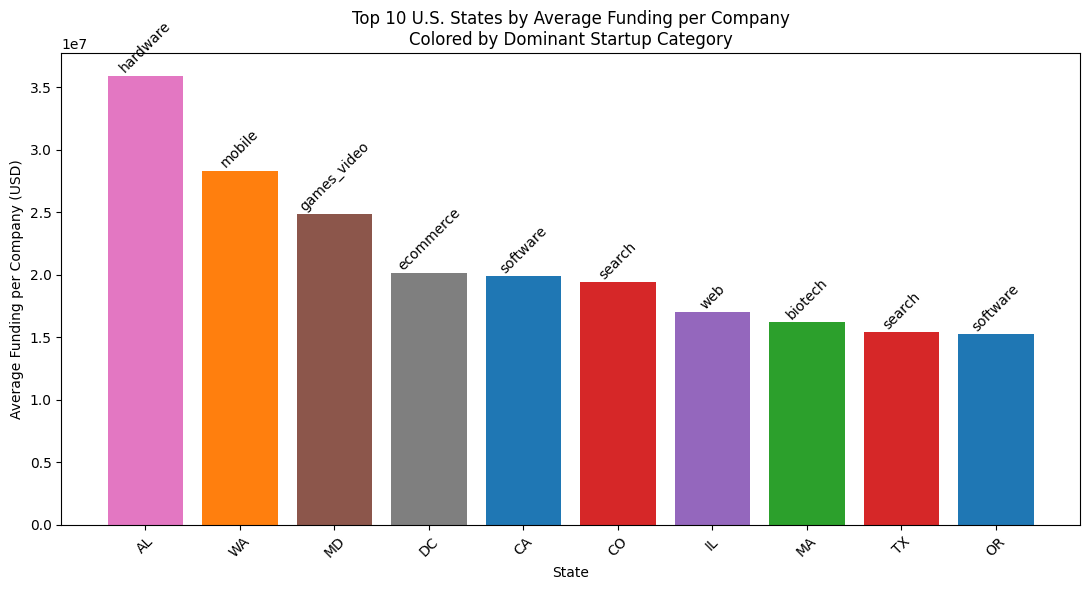

In [ ]:
import matplotlib.pyplot as plt

# Sort and select top 10 states
df_viz = df.to_pandas().sort_values(
    "avg_funding_per_company", ascending=False
).head(10)

# Define a color map for categories
category_colors = {
    "software": "#1f77b4",
    "mobile": "#ff7f0e",
    "biotech": "#2ca02c",
    "search": "#d62728",
    "web": "#9467bd",
    "games_video": "#8c564b",
    "hardware": "#e377c2",
    "ecommerce": "#7f7f7f"
}

# Assign colors based on dominant category
colors = df_viz["dominant_category"].map(category_colors).fillna("#bcbd22")

plt.figure(figsize=(11,6))
bars = plt.bar(
    df_viz["state_code"],
    df_viz["avg_funding_per_company"],
    color=colors
)

plt.title(
    "Top 10 U.S. States by Average Funding per Company\n"
    "Colored by Dominant Startup Category"
)
plt.xlabel("State")
plt.ylabel("Average Funding per Company (USD)")
plt.xticks(rotation=45)

# Annotate bars with dominant category
for bar, category in zip(bars, df_viz["dominant_category"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        category,
        ha="center",
        va="bottom",
        fontsize=10,
        rotation=45
    )

plt.tight_layout()
plt.show()

This chart shows average funding per company by state, with each bar annotated to indicate the dominant business category in that region. The visualization highlights not only funding efficiency but also sector specialization, making it easier to identify regions that combine strong capital allocation with clear industry focus.

**Interpretation:**

*Funding Efficiency Varies by State:*

Smaller markets like Alabama `($35.9M)`, Washington `($28.3M)`, and Maryland `($24.8M)` show the highest average funding per company, indicating concentrated investment opportunities and the potential for high-impact, focused deals.
Large Hubs Are Competitive: California, despite leading in total funding `($85.2B)` and number of startups `(3,575)`, has a lower average funding per company `($19.9M)`, reflecting a highly competitive ecosystem with capital spread across many ventures.

Sector Specialization Drives Opportunity:

Washington → Mobile

Maryland → Video Games

Massachusetts → Biotech

California → Software

Texas & Colorado → Search

*Strategic Implications*: States combining high funding efficiency with clear sector dominance offer differentiated deal flow and reduced competition, making them attractive for focused investments.

*Investment Approaches:*

Focused bets in smaller, high-efficiency markets to maximize impact per investment.
Broad portfolio engagement in large ecosystems to access abundant deal flow, accepting moderate competition.

**Overall Insight**: Horizon Ventures can optimize capital deployment by targeting regions where funding efficiency aligns with sector strengths, improving potential returns and positioning the firm in less saturated markets. These patterns suggest that investment opportunities are not solely concentrated in the largest hubs. Regions that combine high funding efficiency with clear sector dominance can provide Horizon Ventures with differentiated deal flow, reduced competition, and sector-specific expertise. From a business perspective, this geographic insight allows the firm to strategically allocate capital to markets where high-impact investments are possible, balancing between the abundant but competitive opportunities in major hubs and the more concentrated, high-return potential in smaller, specialized markets.

#Task 5: Executive Summary

Horizon Ventures can use the Crunchbase data to target a portfolio that balances scale in mature hubs with high‑impact, focused bets in specialized, capital‑efficient regions. The analysis highlights three main themes: funding is highly concentrated in a few categories and companies, funding round sizes are very uneven within each year, and geographic “sweet spots” exist where fewer startups capture more capital on average.

# Key Insight 1: Funding Concentrates in Category Leaders
Across major categories with at least 10 companies, a small number of firms capture a disproportionate share of capital. In advertising, for example, the top company `(Adknowledge)` has raised about `248M` while the 10th ranked company `(Coremetrics)` is near `91M`, even though both operate in the same category. This steep drop‑off repeats across other categories, indicating that investors crowd into a limited set of perceived winners while most competitors remain significantly underfunded.

Why this matters:
- Entering a category late with undifferentiated companies is unlikely to generate outsized returns because capital and attention are already locked into a few leaders.
- However, strong founders with clear differentiation in these same categories can still attract substantial capital if they show credible potential to join this “leader” tier.

#Key Insight 2: Long‑Run Category Momentum, Short‑Term Volatility
Running‑total analysis by year shows that categories such as advertising and software exhibit steadily rising cumulative funding over time, even though their year‑to‑year funding amounts fluctuate. In advertising, annual funding swings from moderate to very large years, but the cumulative curve consistently trends upward, especially after the mid‑2000s. This pattern indicates long‑term investor conviction in these sectors despite short‑term cycles and macro shocks.

Why this matters:
- Horizon Ventures can treat categories with strong cumulative growth as structurally attractive themes, planning multi‑year theses rather than reacting to single‑year spikes or dips.
- Volatility at the annual level underscores the importance of having an ongoing pipeline in core categories so that the firm can deploy capital when valuations or round sizes become temporarily more favorable.

#Key Insight 3: Funding Rounds Are Highly Uneven Within Each Year
When individual funding rounds are compared against their own year’s average, most rounds cluster around or below the annual mean while a small group sits dramatically above it. These outlier rounds can be many multiples of the typical deal size for that year, and they significantly pull up the average. In practice, this means the “average” is not representative of a typical deal; it is shaped by a handful of very large rounds.

Why this matters:
- Investment risk and reward are not evenly distributed; missing a small set of breakout rounds can materially reduce vintage‑year performance.
- Benchmarking deals purely against annual averages can be misleading; Horizon should instead benchmark by stage, sector, and expected outlier potential, and accept that a small number of big wins will drive returns.

# Key Insight 4: Geographic “Efficiency” Beats Sheer Volume
By combining company‑level funding with office locations, the analysis compares states on both total capital and average funding per company. California dominates in total funding `(~85.2B)` and company count `(3,575)`, but its average funding per company is `~19.9M` because capital is spread over many startups. In contrast, smaller markets like Alabama `(~35.9M)`, Washington `(~28.3M)`, and Maryland `(~24.8M)` have the highest average funding per company among states with at least 10 startups, indicating more concentrated capital per firm.

Why this matters:
- Large hubs like California provide abundant deal flow but also intense competition, higher noise, and more “tourist capital.”​
- Smaller but efficient markets can offer higher impact per investment, especially where local ecosystems channel most capital into a relatively small set of credible companies.

#Key Insight 5: States Have Clear Sector Specializations
Overlaying dominant categories on funding efficiency reveals distinct regional specializations. Washington is dominated by mobile startups, Maryland by video‑game companies, Massachusetts by biotech, and California by software, while states like Texas and Colorado lean toward search and related web technologies. These patterns suggest that sectors cluster where talent, incumbents, and supporting infrastructure already exist.​

Why this matters:
- Sector specialization reduces sector risk for investors: local networks, talent pools, and acquirers make it easier for startups in the dominant category to scale and exit.
- For Horizon Ventures, partnering with local ecosystems in specialized states can improve sourcing, diligence, and post‑investment support in those focus categories.

#Recommended Investment Strategy
Primary recommendation:
Focus the next `12-18` months on a barbell strategy that combines:
1. core participation in software and advertising leaders in California and Massachusetts, and
2. concentrated, category‑aligned bets in high‑efficiency states such as Washington (mobile), Maryland (games), and Massachusetts (biotech).

#Evidence and rationale:
- The cumulative funding analysis shows that software‑ and advertising‑related categories have durable, long‑run momentum, making them strong anchors for the portfolio.​
- Category ranking results confirm that a few companies attract the majority of capital in each category, so Horizon should prioritize access to top‑quartile or top‑decile companies, especially in major hubs.​
- State‑level metrics show that Washington, Maryland, and similar high‑efficiency states deliver more funding per company, suggesting that credible companies in those ecosystems receive strong backing and may face less local competition for capital.​
- Sector specialization by state indicates a natural match between these regions and specific themes—mobile in Washington, games in Maryland, biotech in Massachusetts—allowing Horizon to build differentiated theses instead of chasing generic “hot” deals.

#Practical implications:
- Build or deepen relationships with leading founders, repeat entrepreneurs, and top funds in California and Massachusetts for access to later‑stage, large‑round leaders in software and advertising.​
- In parallel, establish focused sourcing channels (local accelerators, university labs, specialized meetups) in Washington and Maryland targeting mobile and gaming startups raising Seed–Series B rounds.​
- Evaluate opportunities using a dual lens: expected ability to be a category leader and alignment with a state‑level specialization where average funding per company is high.

#Data and Analysis Limitations
The Crunchbase dataset is not a complete census of all startups and tends to over‑represent companies that publicly disclose funding, which may bias results toward larger or more visible rounds and ecosystems. Funding associated with companies that have multiple offices was attributed equally to each location due to the absence of deal‑level location data, potentially overstating capital in some regions and understating it in others. Category labels and headcount figures are based on self‑reported or historical information and may be noisy or outdated, so findings should be combined with qualitative market intelligence before final investment decisions.